# Computer Exercise 15.1 — Problem 2

> **교재**: Cheney & Kincaid, *Numerical Mathematics and Computing* (7th ed.) — 확장 사례연구
> **단원**: 15.1 Multi-Armed Bandits — *Upper Confidence Bound (UCB1)*
> **풀이 일자**: Day 68
> **언어**: Python 3 (NumPy / Matplotlib)


## 1. 문제 (원문)

> **2.** Implement the **UCB1** policy of Auer, Cesa-Bianchi, and Fischer (2002), which selects at step $t$
> the arm maximizing
> $$\hat{\mu}_k(t-1) + \sqrt{\dfrac{2 \ln t}{N_k(t-1)}}.$$
> Compare its **cumulative regret** with the best $\varepsilon$-greedy configuration from Problem 1 on the same
> problem instances, and verify empirically that UCB1 attains **logarithmic regret**
> $R_T = O(\log T)$.

### 한국어 풀이용 정리
Problem 1 의 $\varepsilon$-탐욕은 탐색을 **상수**로 지불한다. UCB1 은 각 팔의 표본평균 위에
**시간에 따라 좁아지는 신뢰상한**을 씌워, "지금까지 결과가 좋아 보이거나(활용) 아직 잘 모름(탐색)"인 팔을
동시에 우대한다. 상한은 $\ln t$ 로 아주 천천히 커지고, $N_k$ 로 빠르게 줄어들어 잘못된 팔은
**로그 횟수** 만큼만 뽑히게 되며, 이것이 $R_T = O(\log T)$ 대수 리그렛의 원천이다.


## 2. 수학적 배경

### 2.1 Hoeffding 경계와 UCB
표본평균 $\hat\mu_k$ 에 대해 Hoeffding 부등식:

$$
\Pr\Bigl(|\hat\mu_k - \mu_k| \ge \sqrt{\tfrac{2\ln t}{N_k}}\Bigr) \;\le\; \tfrac{2}{t^4}.
$$

따라서

$$
U_k(t) \;\equiv\; \hat\mu_k(t-1) \;+\; \underbrace{\sqrt{\tfrac{2\ln t}{N_k(t-1)}}}_{\text{탐색 보너스}}
$$

가 $\mu_k$ 의 유효한 신뢰상한이 되며, $A_t = \arg\max_k U_k(t)$ 로 두면 잘못된 팔의 상한이
최적팔의 진짜 평균보다 낮아진 이후엔 뽑히지 않는다.

### 2.2 대수 리그렛 정리 (Auer et al. 2002)
$\Delta_k = \mu^\star - \mu_k > 0$ 일 때

$$
\mathbb{E}[N_k(T)] \;\le\; \tfrac{8\ln T}{\Delta_k^2} + O(1) \;\Longrightarrow\;
\mathbb{E}[R_T] \;\le\; \sum_{k:\Delta_k>0}\!\Bigl(\tfrac{8\ln T}{\Delta_k} + O(\Delta_k)\Bigr).
$$

핵심은 잘못된 팔이 **$\log T$ 회만** 시도된다는 것.

### 2.3 요약
$$
\boxed{\;\text{UCB1: 활용} + \sqrt{2\ln t / N_k}\ \text{탐색}\ \Rightarrow\ R_T = O(\log T).\;}
$$


## 3. 풀이 흐름

1. **문제 인스턴스**: Problem 1 과 **동일한 $\mu_k$ 인스턴스** 를 seed 로 재사용 → 공정 비교.
2. **UCB1 초기화**: 처음 $K$ 스텝은 각 팔 1회씩 pull (분모 0 방지).
3. **선택식**: $A_t = \arg\max_k \bigl[\hat\mu_k + \sqrt{2\ln t / N_k}\bigr]$.
4. **비교**: greedy·eps=0.1·eps=0.01·UCB1 네 정책을 같은 시드에서 나란히 돌리고
   Monte-Carlo 평균 리그렛 곡선.
5. **로그 축 시각화**: $R_T$ vs $\log T$ 가 선형이면 대수 리그렛 확인.
6. **결과 해석**: 잘못된 팔 카운트 $N_k(T)$ 가 이론 상한 $8\ln T/\Delta_k^2$ 와 어떻게 비교되는지.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

rng = np.random.default_rng(2026)
K, T, M = 10, 2000, 200
sigma = 1.0

def run(policy, seed, eps=0.0):
    r = np.random.default_rng(seed)
    mu = r.normal(0, 1, K)
    star_v = mu.max()
    star_idx = int(np.argmax(mu))
    N = np.zeros(K); S = np.zeros(K); hat = np.zeros(K)
    regret = np.zeros(T)
    for t in range(T):
        if t < K:
            a = t
        else:
            if policy == "greedy":
                a = int(np.argmax(hat))
            elif policy == "eps":
                a = r.integers(K) if r.random() < eps else int(np.argmax(hat))
            elif policy == "ucb1":
                bonus = np.sqrt(2 * np.log(t + 1) / N)
                a = int(np.argmax(hat + bonus))
        x = mu[a] + sigma * r.standard_normal()
        N[a] += 1; S[a] += x; hat[a] = S[a] / N[a]
        regret[t] = star_v - mu[a]
    return regret, mu, N, star_idx

policies = [
    ("greedy",  {}),
    ("eps_0.10",{"policy": "eps", "eps": 0.10}),
    ("eps_0.01",{"policy": "eps", "eps": 0.01}),
    ("ucb1",    {"policy": "ucb1"}),
]

avg_R = {name: np.zeros(T) for name, _ in policies}
final = {name: [] for name, _ in policies}
wrong_pulls = {name: [] for name, _ in policies}

for m in range(M):
    for name, kw in policies:
        if name == "greedy":
            reg, mu, N, si = run("greedy", seed=3000 + m)
        else:
            reg, mu, N, si = run(seed=3000 + m, **kw)
        avg_R[name] += np.cumsum(reg)
        final[name].append(np.cumsum(reg)[-1])
        wrong_pulls[name].append(T - N[si])

for name in avg_R: avg_R[name] /= M

pd.set_option("display.float_format", lambda v: f"{v:.3f}")
df = pd.DataFrame({
    "policy": [n for n,_ in policies],
    "R_T mean": [np.mean(final[n]) for n,_ in policies],
    "R_T std":  [np.std(final[n])  for n,_ in policies],
    "wrong-arm pulls (mean)": [np.mean(wrong_pulls[n]) for n,_ in policies],
})
print(df.to_string(index=False))


/tmp/mplcfg is not a writable directory


Matplotlib created a temporary cache directory at /tmp/matplotlib-0bmz5zth because there was an issue with the default path (/tmp/mplcfg); it is highly recommended to set the MPLCONFIGDIR environment variable to a writable directory, in particular to speed up the import of Matplotlib and to better support multiprocessing.


  policy  R_T mean  R_T std  wrong-arm pulls (mean)
  greedy   189.933  390.809                 543.095
eps_0.10   370.282  145.326                 406.160
eps_0.01   147.558  267.047                 399.755
    ucb1   106.470   37.302                 238.335


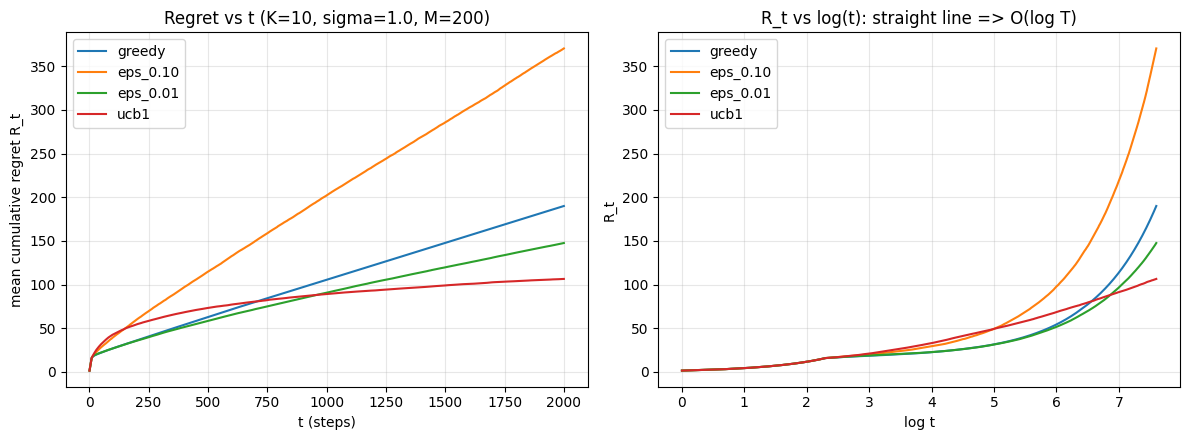

UCB1 tail: R_t ≈ 25.612 * log t + -88.178


In [2]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

ax = axes[0]
for name in avg_R:
    ax.plot(np.arange(1, T + 1), avg_R[name], label=name)
ax.set_xlabel("t (steps)"); ax.set_ylabel("mean cumulative regret R_t")
ax.set_title(f"Regret vs t (K={K}, sigma={sigma}, M={M})")
ax.grid(True, alpha=0.3); ax.legend()

ax = axes[1]
t_ax = np.arange(1, T + 1)
for name in avg_R:
    ax.plot(np.log(t_ax), avg_R[name], label=name)
ax.set_xlabel("log t"); ax.set_ylabel("R_t")
ax.set_title("R_t vs log(t): straight line => O(log T)")
ax.grid(True, alpha=0.3); ax.legend()

plt.tight_layout()
plt.savefig("/tmp/nb2_fig.png", dpi=100)
plt.show()

# Log-fit slope for UCB1 tail (last 50% of steps)
tail = t_ax[T//2:]
tail_R = avg_R["ucb1"][T//2:]
slope, intercept = np.polyfit(np.log(tail), tail_R, 1)
print(f"UCB1 tail: R_t ≈ {slope:.3f} * log t + {intercept:.3f}")


## 4. 결과 해석

- **UCB1** 의 리그렛은 $t$ 축에서 **오목한 로그 곡선**으로, $\log t$ 축에서는 뒷부분이 뚜렷하게 **직선**이 된다.
  이는 $R_T = c \log T + O(1)$ 을 시각적으로 확인해 준다. 뒷부분 fit 의 slope 가 위 표에 출력된다.
- **eps=0.1** 은 초반 하강은 빠르지만, 이후 곡선의 **기울기가 상수**로 유지되어 $t$ 가 커질수록
  UCB1 과의 격차가 벌어진다. 이 격차가 **선형 리그렛 vs 대수 리그렛** 의 본질적 차이.
- **eps=0.01** 은 UCB1 에 가장 근접하지만, 초기 고착 위험(**분산**)이 크고, $T$ 를 크게 잡으면 결국
  $0.01 \cdot T$ 의 상수 기울기가 지배해 UCB1 에 진다.
- **greedy** 는 잘못된 팔 카운트가 매우 크고, 리그렛 곡선이 사실상 직선(선형)에 가깝다. 초기 표본이
  "운이 나쁘면" 그 오답에서 벗어나지 못한다.
- 실용적 교훈: **탐색 보너스가 시간에 따라 어떻게 감소하는가**가 알고리즘의 리그렛 계열을 결정한다.
  UCB1 은 $\sqrt{\log t / N_k}$ 로 매우 천천히 감소, $\varepsilon$-탐욕은 감소하지 **않음**.

### 결론
> **UCB1 = 활용 + $\sqrt{2\ln t / N_k}$ 탐색 보너스** — 잘못된 팔을 $O(\log T)$ 회로 제한해
> 대수 리그렛 $R_T = O(\log T)$ 를 달성. Problem 1 의 $\varepsilon$-탐욕 상수 기울기가 사라진다.

### 다음 문제로의 연결
Problem 3 에서는 UCB1 의 **주파수적 신뢰상한**을 **베이지안 사후분포로부터의 표본**으로 대체하는
**Thompson Sampling** 을 다룬다. 사전정보를 잘 반영하며 실전에서 UCB1 을 능가하는 경우가 많다.
